## Prosta regresja liniowa

### Importowanie bibliotek
1. sklearn.linear_model - liniowe model w bibliotece sklearn
2. seaborn - biblioteka dzięki której wykresy zrobione w matplotli wyglądają lepiej
3. komenda *sns.set()* powoduje, że polecenia w matplotlib są wywoływane w seaborn 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

Wczytywanie danych

In [2]:
data = pd.read_csv('GPA1.csv')

Każdy wiersz reprezentuje jednego studenta:

SAT (Scholastic Assessment Test) to test powszechnie używany przy przyjęciach do college'y w USA

SAT = Critical Reading + Mathematics + Writing

GPA (Grade Point Average) to średnia ocen ze studiów 

Zakres średniej ocen (grade point average - GPA) na uczelniach w Stanach Zjednoczonych jest różny, ale zazwyczaj waha się od 0,0 do 4,0. Najczęściej używaną skalą GPA jest skala 0-4, gdzie

* 4 oznacza ocenę „A” („doskonale”),
* 3 oznacza ocenę „B” („dobrze”),
* 2 oznacza ocenę „C” („średnio”),
* 1 oznacza ocenę „D” („poniżej średniej”) 
* 0 oznacza ocenę „F” („fail”).

SAT to ustandaryzowany test stosowany przy rekrutacji na studia w Stanach Zjednoczonych. Mierzy gotowość ucznia do pracy na poziomie uczelni i ocenia umiejętności, takie jak czytanie ze zrozumieniem, umiejętność pisania i biegłość matematyczna. SAT jest oceniany w skali od 400 do 1600, przy czym 1600 to najwyższy możliwy wynik.

In [3]:
data

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83
...,...,...
79,1936,3.71
80,1810,3.71
81,1987,3.73
82,1962,3.76


Stworzymy model regresji liniowej, za pomocą którego będziemy przewidywać średnią ocen ze studiów (GPA) na podstawie testu SAT. Jest jasne, że istnieje zależność przyczynowo-skutkowa pomiędzy tymi zmiennymi. 

Pamiętajmy, że model regresji powinien odpowiadać zależności przyczynowo-skutkowej, która ma sens i znaczenie. 

In [4]:
y = data['GPA']
x = data['SAT']

Rysowanie wykresu punktowego

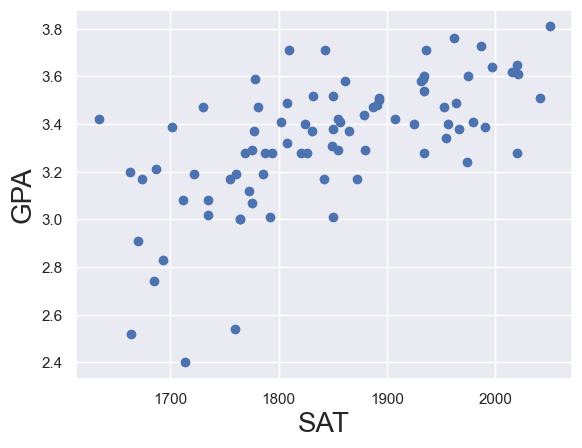

In [5]:
plt.scatter(x,y)
plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.show()

Równianie regresji $\hat{y}=b_0+b_1x_1$ można zapisać $\hat{y}=b_0*1+b_1x_1$ lub
$\hat{y}=[1,x_1]\begin{bmatrix}b_0\\b_1\end{bmatrix}$

In [6]:
# Sklearn przyjmuje zmienną x tylko w postaci 2D array czyli macierzy
# w tym celu musimy zmienić kształ zmiennej x
# ta operacja jest konieczna tylko wtedy, gdy x ma wymiar 1
#x_matrix = x.values.reshape(84,1)
X_simple = x.values.reshape(-1,1)
print('Wymiar x: ', x.shape, 'Wymiar X_simple: ', X_simple.shape)
print('x to wektor długości 84: ',np.array(x))
print('X_simple to macierz 84x1: ',X_simple)

Wymiar x:  (84,) Wymiar X_simple:  (84, 1)
x to wektor długości 84:  [1714 1664 1760 1685 1693 1670 1764 1764 1792 1850 1735 1775 1735 1712
 1773 1872 1755 1674 1842 1786 1761 1722 1663 1687 1974 1826 1787 1821
 2020 1794 1769 1934 1775 1855 1880 1849 1808 1954 1777 1831 1865 1850
 1966 1702 1990 1925 1824 1956 1857 1979 1802 1855 1907 1634 1879 1887
 1730 1953 1781 1891 1964 1808 1893 2041 1893 1832 1850 1934 1861 1931
 1933 1778 1975 1934 2021 2015 1997 2020 1843 1936 1810 1987 1962 2050]
X_simple to macierz 84x1:  [[1714]
 [1664]
 [1760]
 [1685]
 [1693]
 [1670]
 [1764]
 [1764]
 [1792]
 [1850]
 [1735]
 [1775]
 [1735]
 [1712]
 [1773]
 [1872]
 [1755]
 [1674]
 [1842]
 [1786]
 [1761]
 [1722]
 [1663]
 [1687]
 [1974]
 [1826]
 [1787]
 [1821]
 [2020]
 [1794]
 [1769]
 [1934]
 [1775]
 [1855]
 [1880]
 [1849]
 [1808]
 [1954]
 [1777]
 [1831]
 [1865]
 [1850]
 [1966]
 [1702]
 [1990]
 [1925]
 [1824]
 [1956]
 [1857]
 [1979]
 [1802]
 [1855]
 [1907]
 [1634]
 [1879]
 [1887]
 [1730]
 [1953]
 [1781]
 [189

Konieczność zmiany kształtu wektora x na macierz może się wydawać kłopotliwe. Wynika, to z faktu, że sklearn służy do analizowania danych **wielowymiarowych**. W przypadku danych jednowymiarowych jest do tego wiele prostszych narzędzi. 

In [7]:
# Zaczynamy od stworzenia nowego obiektu klasy LinearRegression
reg = LinearRegression()

# pierwsza zmienna metody fit() to zmienna niezależna, druga to zmienna zależna
reg.fit(X_simple,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Współczynniki regresji

In [8]:
print('b_1=',reg.coef_[0], 'b_0', reg.intercept_)

b_1= 0.0016556880500928136 b_0 0.27504029966028076


Po zaokrągleniu $b_1=0.0017$ oraz $b_0=0.2750$. Zatem prosta regresji ma postać

$\hat{y}=0.2750 + 0.0017\cdot x_1$

$\text{GPA}=0.2750 + 0.0017\cdot\text{SAT}$

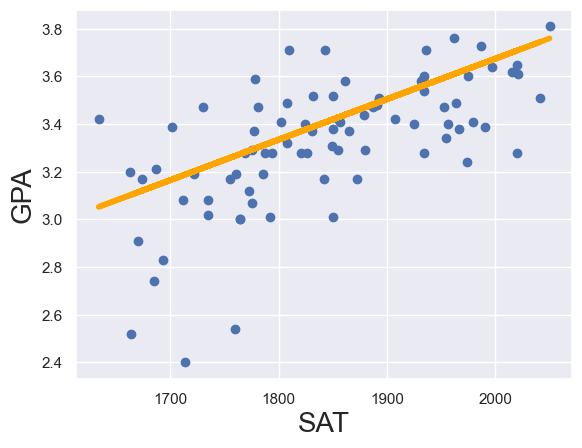

In [9]:
plt.scatter(X_simple,y)
yhat = 0.2750 + 0.0017*X_simple  # definiowanie prostej regresji
plt.plot(X_simple,yhat,lw=4,c='orange',label='prosta regresji')  # rysowanie prostej regresji
plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.show()

Dokonajmy predykcji GPA dla studentów z wynikiem SAT równym 1700, 1800, 1900, 2000:

$\text{GPA}=0.2750 + 0.0017\cdot 1700=$

$\text{GPA}=0.2750 + 0.0017\cdot 1800=$

$\text{GPA}=0.2750 + 0.0017\cdot 1900=$

$\text{GPA}=0.2750 + 0.0017\cdot 2000=$


In [10]:
sats = [1700, 1800, 1900, 2000]
for sat in sats:
  print('Przewidywana wartość GPA dla studenta z wynikiem SAT =',sat,'wynosi', '{:.2f}'.format(0.275+0.0017*sat))

Przewidywana wartość GPA dla studenta z wynikiem SAT = 1700 wynosi 3.16
Przewidywana wartość GPA dla studenta z wynikiem SAT = 1800 wynosi 3.33
Przewidywana wartość GPA dla studenta z wynikiem SAT = 1900 wynosi 3.50
Przewidywana wartość GPA dla studenta z wynikiem SAT = 2000 wynosi 3.67


Współczynnik determinacji $R^2$

In [11]:
reg.score(X_simple,y)

0.40600391479679754

# Regresja wielokrotna i skorygowany $R^2$

### Regresja
Dokumentacja: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

## Biblioteki

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
import seaborn
seaborn.set()

## Wczytywanie danych

Do poprzedniego zbioru danych dołożona została kolumna z losowymi liczbami

In [13]:
data = pd.read_csv('GPA_random.csv')

In [14]:
# Rzut ona na dane
data

,SAT,GPA,"Rand 1,2,3"
0,1714,2.40,1
1,1664,2.52,3
2,1760,2.54,3
3,1685,2.74,3
4,1693,2.83,2
...,...,...,...
79,1936,3.71,3
80,1810,3.71,1
81,1987,3.73,3
82,1962,3.76,1


In [15]:
# Statystyki opisowe
data.describe()

,SAT,GPA,"Rand 1,2,3"
count,84.000000,84.000000,84.000000
mean,1845.273810,3.330238,2.059524
std,104.530661,0.271617,0.855192
min,1634.000000,2.400000,1.000000
25%,1772.000000,3.190000,1.000000
50%,1846.000000,3.380000,2.000000
75%,1934.000000,3.502500,3.000000
max,2050.000000,3.810000,3.000000


## Model regresji wielokrotnej

In [16]:
# zmienna zależna
y = data ['GPA']
# zamienne niezależne
X_random = data [['SAT','Rand 1,2,3']]

In [17]:
reg = LinearRegression()
reg.fit(X_random,y)
reg.score(X_random,y)

0.4066811952814283

### Wzór na skorygowne (adjusted) R^2

$R^2_{adj.} = 1 - (1-R^2)*\frac{n-1}{n-p-1}$ (dla modelu ze stałą)

In [18]:
# By wyznaczyć n i p znajdźmy kształt macierzy x
X_random.shape

(84, 2)

In [19]:
r2 = reg.score(X_random,y)
 
n = X_random.shape[0]

p = X_random.shape[1]

# Ze wzoru na adjusted R^2
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
adjusted_r2

0.3920313482513401

# Jak sobie radzić ze zmiennymi kategorycznymi w regresji liniowej - zmienne binarne

## Import bibliotek

In [20]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## Wczytywanie danych

In [21]:
raw_data = pd.read_csv('GPA2.csv')

In [22]:
raw_data

,SAT,GPA,Attendance
0,1714,2.40,No
1,1664,2.52,No
2,1760,2.54,No
3,1685,2.74,No
4,1693,2.83,No
...,...,...,...
79,1936,3.71,Yes
80,1810,3.71,Yes
81,1987,3.73,No
82,1962,3.76,Yes


'Attendance' to zmienna kategoryczna mówiąca o tym, czy student był na conajmniej 75% zajęć

## Zamiana yes/no na 1/0

In [23]:
data = raw_data.copy()
data['Attendance'] = data['Attendance'].map({'Yes': 1, 'No': 0})

data

,SAT,GPA,Attendance
0,1714,2.40,0
1,1664,2.52,0
2,1760,2.54,0
3,1685,2.74,0
4,1693,2.83,0
...,...,...,...
79,1936,3.71,1
80,1810,3.71,1
81,1987,3.73,0
82,1962,3.76,1


In [24]:
# Statystyki opisowe
data.describe()

,SAT,GPA,Attendance
count,84.000000,84.000000,84.000000
mean,1845.273810,3.330238,0.464286
std,104.530661,0.271617,0.501718
min,1634.000000,2.400000,0.000000
25%,1772.000000,3.190000,0.000000
50%,1846.000000,3.380000,0.000000
75%,1934.000000,3.502500,1.000000
max,2050.000000,3.810000,1.000000


## Regresja

In [25]:
# Zmienna zależna
y = data ['GPA']
# zmienne niezależne
X = data [['SAT','Attendance']]

In [26]:
reg = LinearRegression()
reg.fit(X,y)
reg.score(X,y)

0.5654390486739878

In [27]:
print('b_0', reg.intercept_, 'b_1=',reg.coef_[0],'b_2=',reg.coef_[1])

b_0 0.6438504592803032 b_1= 0.0013998015651245364 b_2= 0.2226440877296415


Z tabeli odczytujemy wartości współczynników regresji: const - $b_0 = 0.6439$, SAT - $b_1= 0.0014$, Attendance - $b_2= 0.2226$

Zatem model ma postać: $GPA=0.6439 + 0.0014\cdot SAT+0.2226\cdot Attendance$. 

Zmienna $Attendance$ przyjmuje dwie wartości. Dla studentów, którzy mieli frekwencję powyżej 75% $Attendance=1$ i wtedy 
$$GPA=0.6439 + 0.0014\cdot SAT+0.2226\cdot 1=0.8665+0.0014\cdot SAT$$
Dla studentów, którzy mieli frekwencję poniżej 75% $Attendance=0$ i wtedy 
$$GPA=0.6439 + 0.0014\cdot SAT+0.2226\cdot 0=0.6439 + 0.0014\cdot SAT$$


## Wykres prostej regresji na wykresie punktowym

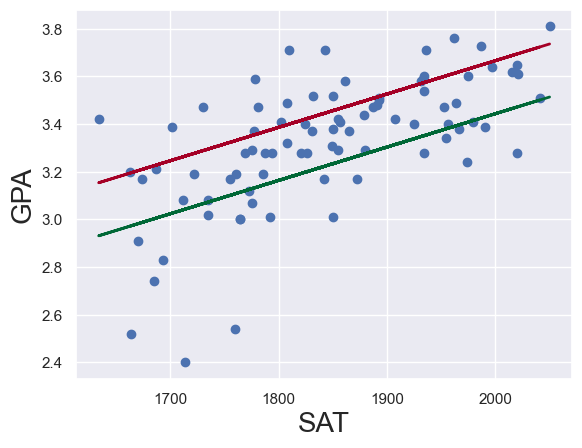

In [28]:
plt.scatter(data['SAT'],y)
# dwa rówananie regresji w zależności od tego, czy zmienna 'Attendace' jest równa 'yes' czy 'no'
yhat_no = 0.6439 + 0.0014*data['SAT']
yhat_yes = 0.8665 + 0.0014*data['SAT']
 
plt.plot(data['SAT'],yhat_no, lw=2, c='#006837')
plt.plot(data['SAT'],yhat_yes, lw=2, c='#a50026')

plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

## Dwa wykresy + kolory punktów w zależności od frekwencji

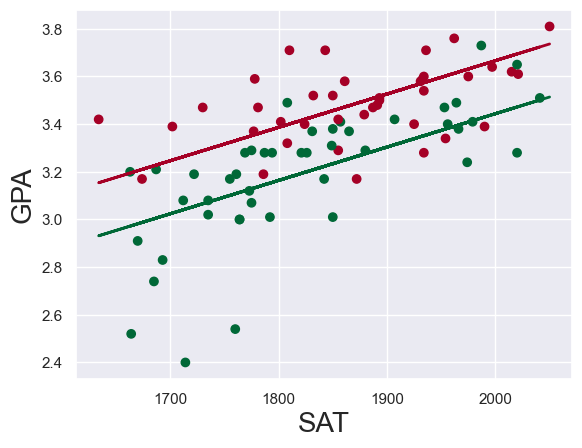

In [29]:
# Punkty wykresu punktowego kolorujemy przy użyciu zmiennej 'Attendace'
plt.scatter(data['SAT'],data['GPA'], c=data['Attendance'],cmap='RdYlGn_r')

yhat_no = 0.6439 + 0.0014*data['SAT']
yhat_yes = 0.8665 + 0.0014*data['SAT']

fig = plt.plot(data['SAT'],yhat_no, lw=2, c='#006837')
fig = plt.plot(data['SAT'],yhat_yes, lw=2, c='#a50026')
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

## Dodanie prostej regresji nieuwzględniającej frekwencji

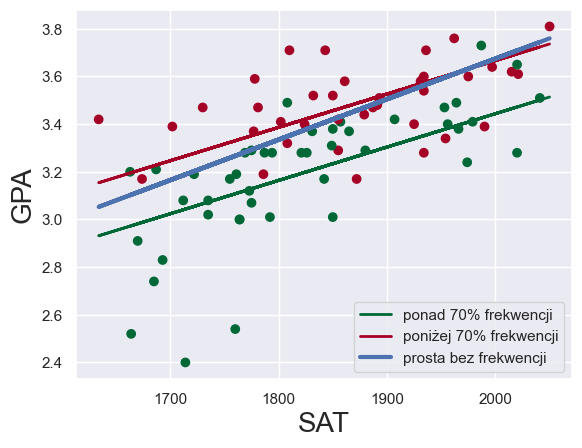

In [30]:
plt.scatter(data['SAT'],data['GPA'], c=data['Attendance'],cmap='RdYlGn_r')

yhat_no = 0.6439 + 0.0014*data['SAT']
yhat_yes = 0.8665 + 0.0014*data['SAT']
# oryginalna prosta regresji
yhat = 0.0017*data['SAT'] + 0.275

plt.plot(data['SAT'],yhat_no, lw=2, c='#006837', label ='ponad 70% frekwencji')
plt.plot(data['SAT'],yhat_yes, lw=2, c='#a50026', label ='poniżej 70% frekwencji')

plt.plot(data['SAT'],yhat, lw=3, c='#4C72B0', label ='prosta bez frekwencji')

plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.legend()
plt.show()

## Użycie funkcji f_regression z modułu feature selection do wyznaczania p-wartości
Dokumentacja: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_regression.html

In [31]:
from sklearn.feature_selection import f_regression

In [32]:
f_regression(X,y)

(array([56.04804786, 33.79842712]), array([7.19951844e-11, 1.13215865e-07]))

In [33]:
p_values = f_regression(X,y)[1]
p_values

array([7.19951844e-11, 1.13215865e-07])

In [34]:
p_values.round(3)

array([0., 0.])

## Tabela podsumowująca regresję liniową

In [35]:
reg_summary = pd.DataFrame(data = X.columns.values, columns=['Features'])
reg_summary

,Features
0,SAT
1,Attendance


In [36]:
reg_summary ['Coefficients'] = reg.coef_
reg_summary ['p-values'] = p_values.round(3)

In [37]:
reg_summary

,Features,Coefficients,p-values
0,SAT,0.001400,0.0
1,Attendance,0.222644,0.0
